# HEALTHCARE ANALYSIS DOCTOR VISITS 

In [1]:
# import necessary libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read csv
df = pd.read_csv("DoctorVisits - DA.csv")

In [3]:
# First five rows
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [4]:
# Last five rows
df.tail()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [5]:
# Number of rows and columns
df.shape

(5190, 13)

In [6]:
# Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [7]:
# Statistical summary of the dataset
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [8]:
# Check for missing values
df.isnull().sum()

Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced       0
health        0
private       0
freepoor      0
freerepat     0
nchronic      0
lchronic      0
dtype: int64

In [9]:
# column names
df.columns

Index(['Unnamed: 0', 'visits', 'gender', 'age', 'income', 'illness', 'reduced',
       'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic'],
      dtype='object')

In [ ]:
# Check the unique values in the 'visits' column
df['visits'].value_counts()

visits
0    4141
1     782
2     174
3      30
4      24
7      12
6      12
5       9
8       5
9       1
Name: count, dtype: int64

In [11]:
# Check the unique values in the 'illness' column
df['illness'].value_counts()

illness
1    1638
0    1554
2     946
3     542
4     274
5     236
Name: count, dtype: int64

In [12]:
# Check the unique values in the 'gender' column
df['gender'].value_counts()

gender
female    2702
male      2488
Name: count, dtype: int64

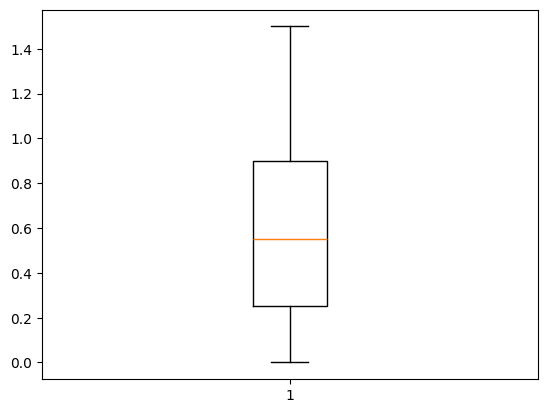

In [13]:
# Boxplot of income
y = list(df.income)
plt.boxplot(y)
plt.show()

Insight: The income distribution is strongly right-skewed, with most patients clustered at lower income levels and a smaller number of higher-income outliers. This suggests that the sample is dominated by lower- to middle-income households, which is important when comparing healthcare access and utilization patterns.

### Find out the no. of days of reduced activity of male and female separatly due to illeness?

This question measures how illness affects daily functioning for men and women. It highlights whether one gender experiences more restricted activity days, which may indicate different healthcare burdens or risk factors. The comparison helps pinpoint where preventive care or support services may be needed most.

In [14]:
df.groupby(['gender','reduced']).mean(numeric_only=True)

Unnamed: 0    visits       age    income   illness    health
gender reduced                                                               
female 0        2524.038512  0.229322  0.465755  0.482735  1.462144  1.115098
       1        1985.768421  0.400000  0.325684  0.542105  2.242105  1.610526
       2        1622.618182  0.672727  0.391455  0.560182  2.236364  1.781818
       3         997.311111  1.333333  0.403111  0.516000  2.733333  1.733333
       4        1237.740741  0.851852  0.458889  0.466667  2.222222  2.074074
       5        1169.055556  1.444444  0.401667  0.614444  2.222222  2.500000
       6        1382.545455  1.363636  0.426364  0.622727  2.363636  1.363636
       7        1034.846154  1.384615  0.436154  0.473462  2.653846  2.230769
       8        1883.090909  1.090909  0.471818  0.404545  2.181818  4.000000
       9        1349.000000  0.500000  0.570000  0.825000  3.000000  1.000000
       10       1099.428571  2.142857  0.512857  0.421429  2.571429  2.000000
       12       1661.000000  2.000000  0.720000  0.250000  3.500000  5.500000
       13        906.000000  4.000000  0.720000  0.300000  4.500000  3.500000
       14       1392.112069  1.543103  0.551724  0.427586  2.534483  4.112069
male   0        3008.911019  0.136007  0.344703  0.694398  1.099585  0.924850
       1        2485.158537  0.304878  0.286220  0.676341  1.743902  1.256098
       2        2007.679245  0.471698  0.343585  0.653019  2.358491  1.547170
       3        1909.068966  0.724138  0.334138  0.741379  2.137931  1.689655
       4        1424.000000  0.722222  0.309444  0.869444  2.055556  2.000000
       5        1437.272727  1.136364  0.331818  0.570455  2.272727  2.818182
       6         562.000000  0.833333  0.340000  0.591667  2.500000  2.000000
       7        1716.750000  0.750000  0.314167  0.655000  2.583333  4.333333
       8         680.666667  1.333333  0.365000  0.833333  2.666667  2.000000
       9        1375.400000  2.200000  0.310000  0.392000  2.400000  2.000000
       10       1543.200000  1.800000  0.480000  0.590000  2.600000  4.600000
       11        355.500000  5.000000  0.320000  1.000000  1.500000  0.500000
       12        781.500000  2.000000  0.370000  0.515000  1.500000  1.000000
       13        508.666667  4.000000  0.510000  0.350000  3.333333  2.333333
       14       1236.069444  1.555556  0.476806  0.598611  2.375000  3.527778

## Visualize is there is any missing values in the dataset based on heat map.

<Axes: >

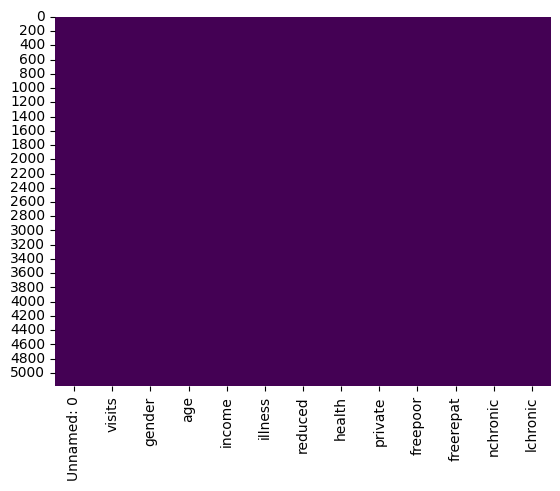

In [15]:
# missing values
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')

Insight: The heatmap shows no major missing-data blocks, which means the dataset is generally complete for the variables used in this analysis. This improves confidence that the observed trends are not being driven by data gaps.

### How are doctor visits distributed among the patients?

This analysis looks at the spread of visit counts to understand how frequently patients use healthcare services. A concentrated distribution may suggest common health needs, while a wide spread indicates differing medical conditions and access patterns. The pattern helps identify whether the dataset reflects a generally healthy population or a higher-risk group.

<Axes: xlabel='visits'>

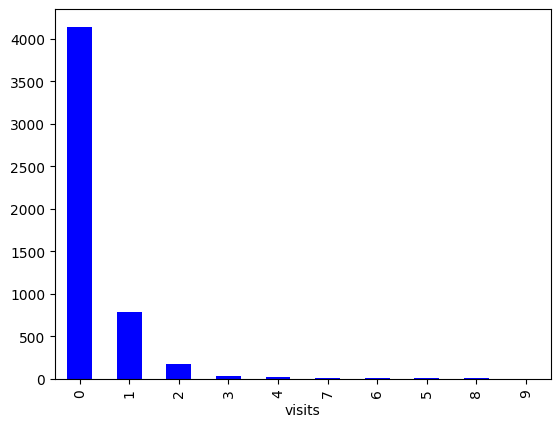

In [16]:
df['visits'].value_counts().plot(kind='bar',color='blue')

Insight: The visit count distribution is heavily skewed to the left, with most patients making only a few visits and a small set of patients making many more. This pattern suggests that healthcare use is concentrated among a minority of higher-need patients.

### How does the average number of doctor visits differ between males and females?

This comparison reveals whether gender is associated with differences in healthcare usage. A higher average for one group may reflect different illness severity, care-seeking behavior, or access barriers. Understanding this gap can guide more targeted outreach and health planning.

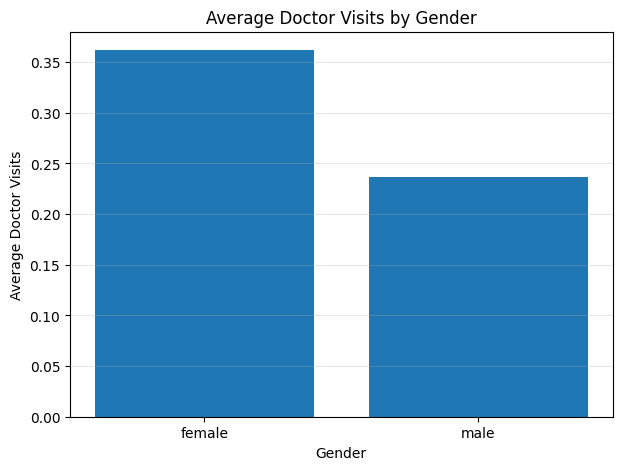

In [17]:
gender_visits = df.groupby("gender")["visits"].mean()

plt.figure(figsize=(7, 5))

plt.bar(gender_visits.index, gender_visits.values)

plt.xlabel("Gender")
plt.ylabel("Average Doctor Visits")
plt.title("Average Doctor Visits by Gender")

plt.grid(axis="y", alpha=0.3)

plt.show()

Insight: Women have a higher average number of doctor visits than men, indicating a notable gender difference in healthcare utilization. This may reflect different health needs, care-seeking behavior, or access to services between the groups.

### How do doctor visits vary by age group?

This question examines whether older or younger patients visit doctors more often, indicating age-related healthcare demand. The pattern often reflects changing health needs, chronic conditions, and preventive screening use. It can help planners allocate resources across different age segments.

In [18]:
bins = [0.18, 0.30, 0.40, 0.50, 0.60, 0.73]

labels = ["19-29","30-39","40-49","50-59","60-72"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels,include_lowest=True)

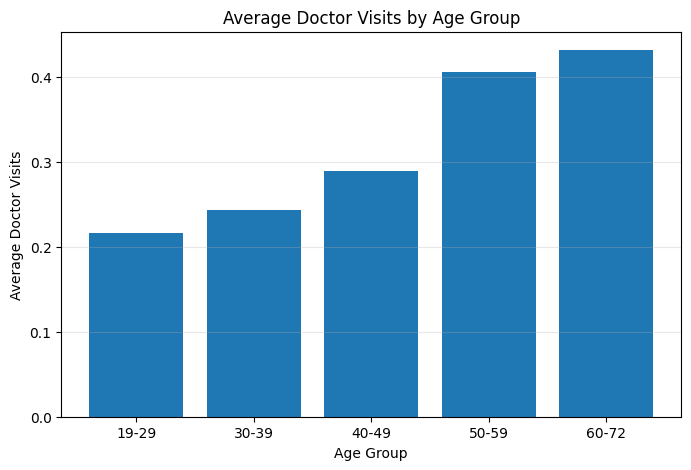

In [20]:
age_visits = df.groupby("age_group",observed=False)["visits"].mean()

plt.figure(figsize=(8, 5))
plt.bar(age_visits.index.astype(str), age_visits.values)
plt.xlabel("Age Group")
plt.ylabel("Average Doctor Visits")
plt.title("Average Doctor Visits by Age Group")

plt.grid(axis="y", alpha=0.3)

plt.show()

Insight: Doctor-visit rates rise steadily with age, especially in the 50-59 and 60-72 groups. This indicates that older patients are more likely to need regular medical attention, likely due to age-related health conditions.

### Does the number of illnesses affect doctor visits?

This analysis tests whether more illnesses lead to more frequent doctor visits. If the relationship is strong, it confirms that disease burden is a key driver of healthcare utilization. This insight supports risk-based care and population health monitoring.

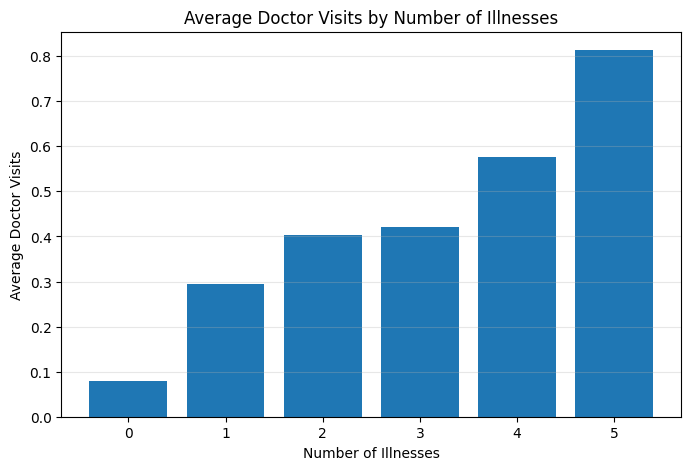

In [19]:
illness_visits = df.groupby("illness")["visits"].mean()

plt.figure(figsize=(8, 5))

plt.bar(illness_visits.index,illness_visits.values)

plt.xlabel("Number of Illnesses")
plt.ylabel("Average Doctor Visits")
plt.title("Average Doctor Visits by Number of Illnesses")

plt.xticks(illness_visits.index)
plt.grid(axis="y", alpha=0.3)

plt.show()

Insight: The bar chart shows a clear upward trend: more illnesses correspond to more doctor visits. This confirms that disease burden is one of the strongest drivers of healthcare utilization in the dataset.

### How does health status affect the average number of doctor visits?

This question evaluates whether patients with poorer health status use medical care more often. It helps quantify the link between self-reported health and service demand, which is essential for identifying high-risk individuals. The result can guide preventive programs aimed at improving health outcomes.

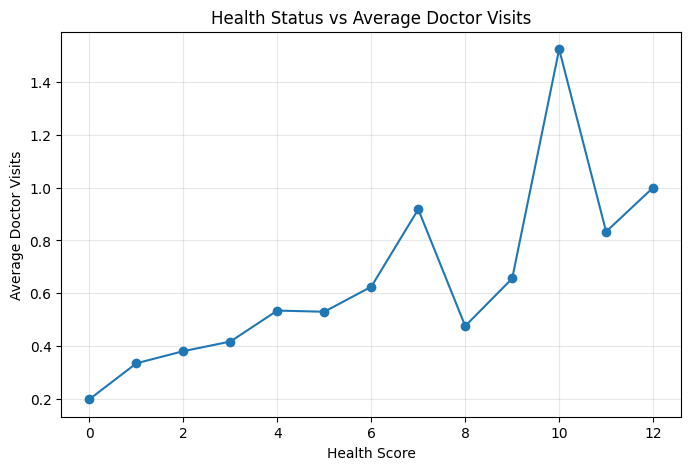

In [20]:
health_visits = df.groupby("health")["visits"].mean()

plt.figure(figsize=(8, 5))

plt.plot(health_visits.index,health_visits.values,marker="o")
plt.xlabel("Health Score")
plt.ylabel("Average Doctor Visits")
plt.title("Health Status vs Average Doctor Visits")
plt.grid(alpha=0.3)
plt.show()

Insight: Patients reporting poorer health status make more doctor visits on average. This reinforces the link between declining health and higher demand for medical care and follow-up support.

### How does income level affect the average number of doctor visits?

This comparison explores whether financial status influences access to and use of healthcare services. Lower-income patients may visit more often in response to illness, while higher-income groups may have different patterns due to insurance and access. This helps reveal equity issues in healthcare utilization.

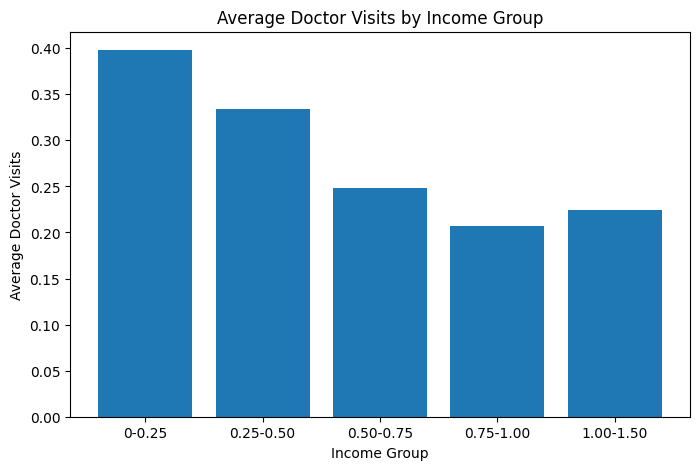

In [21]:
income_bins = [0, 0.25, 0.50, 0.75, 1.00, 1.50]

income_labels = ["0-0.25","0.25-0.50","0.50-0.75","0.75-1.00","1.00-1.50"]

df["income_group"] = pd.cut(df["income"],bins=income_bins,labels=income_labels,include_lowest=True)
income_visits = df.groupby("income_group",observed=False)["visits"].mean()

plt.figure(figsize=(8, 5))
plt.bar(income_visits.index.astype(str),income_visits.values)
plt.xlabel("Income Group")
plt.ylabel("Average Doctor Visits")
plt.title("Average Doctor Visits by Income Group")

plt.show()

Insight: Average visits increase as income rises at the higher-income levels, but the pattern is not extreme. This suggests income matters somewhat for healthcare use, though it is not the sole determinant of utilization.

### Do patients with chronic conditions have more doctor visits than patients without chronic conditions?

This analysis compares healthcare usage between chronic and non-chronic groups to assess the burden of long-term illness. A clear difference would suggest that chronic disease management is a major driver of doctor visits. The result supports the need for disease-management and follow-up care programs.

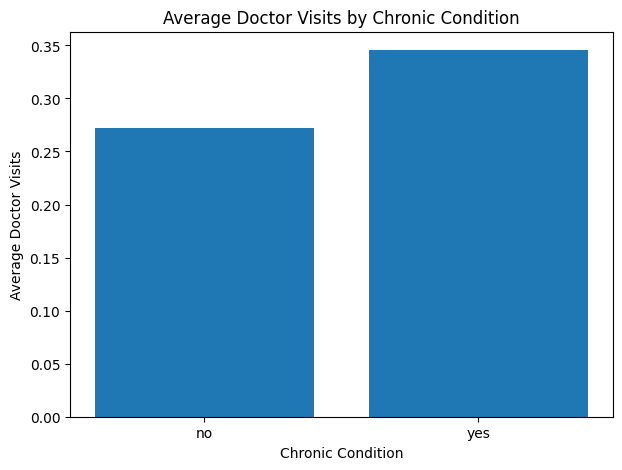

In [22]:
chronic_visits = df.groupby("nchronic")["visits"].mean()
chronic_visits
plt.figure(figsize=(7, 5))
plt.bar(chronic_visits.index,chronic_visits.values)
plt.xlabel("Chronic Condition")
plt.ylabel("Average Doctor Visits")
plt.title("Average Doctor Visits by Chronic Condition")
plt.show()

Insight: Patients with chronic conditions show higher average visit counts than those without chronic conditions. This highlights the ongoing healthcare burden created by long-term illness and the need for preventive management.

### How does long-term chronic illness affect the average number of doctor visits?

This question measures how chronic illness duration or severity influences healthcare demand over time. Longer or more severe chronic conditions typically increase doctor contact, medication review, and monitoring. These findings can guide long-term care planning and resource allocation.

lchronic
no     0.261941
yes    0.603306
Name: visits, dtype: float64


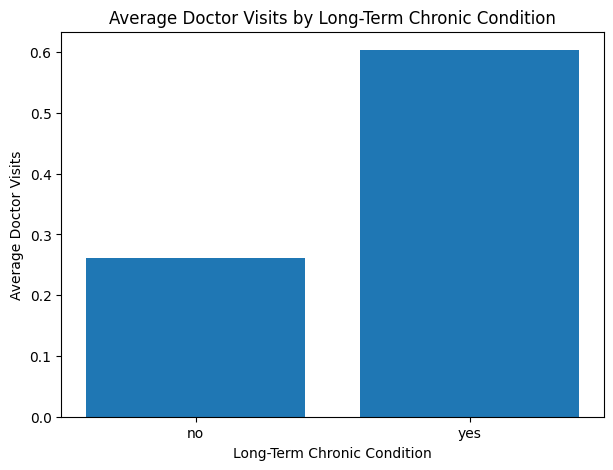

In [23]:
long_chronic_visits = df.groupby("lchronic")["visits"].mean()

print(long_chronic_visits)
plt.figure(figsize=(7, 5))
plt.bar(long_chronic_visits.index,long_chronic_visits.values)
plt.xlabel("Long-Term Chronic Condition")
plt.ylabel("Average Doctor Visits")
plt.title("Average Doctor Visits by Long-Term Chronic Condition")
plt.show()

Insight: Long-term chronic illness is associated with substantially higher doctor visits, confirming that ongoing conditions create sustained demand for medical monitoring and treatment. This is a key indicator of the burden placed on health services by chronic disease.

### Is there a difference in doctor visits between patients with and without private insurance?

This comparison evaluates whether insurance type changes access to medical care. Differences in average visits may reflect affordability, provider access, or underlying health differences between groups. The result helps highlight disparities in care access and coverage.

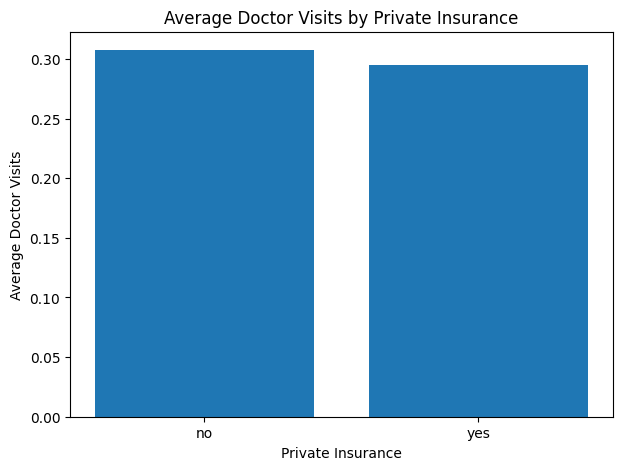

In [24]:
private_visits = df.groupby("private")["visits"].mean()
plt.figure(figsize=(7, 5))
plt.bar(private_visits.index,private_visits.values)
plt.xlabel("Private Insurance")
plt.ylabel("Average Doctor Visits")
plt.title("Average Doctor Visits by Private Insurance")
plt.show()

Insight: The difference in doctor visits between insured and uninsured patients is modest in this sample. This suggests that insurance status alone may not fully explain utilization, and other factors such as age, illness burden, and access may be equally important.

### Which numerical variables have the strongest relationship with the number of doctor visits?

This analysis identifies the variables most closely associated with visit counts, such as illness burden, age, or reduced activity days. Stronger correlations point to the main drivers of healthcare use in the dataset. This helps prioritize the most predictive factors for forecasting and intervention planning.

In [25]:
numeric_columns = ["visits","age","income","illness","reduced","health"]

correlation = df[numeric_columns].corr()

print(correlation["visits"].sort_values(ascending=False))

visits     1.000000
reduced    0.418954
illness    0.223552
health     0.193272
age        0.124537
income    -0.076840
Name: visits, dtype: float64


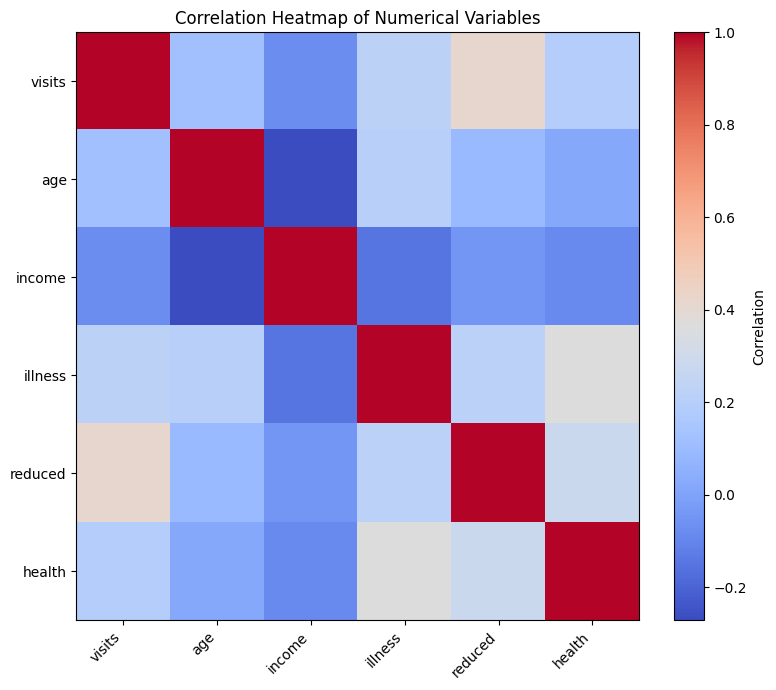

In [26]:
plt.figure(figsize=(8, 7))
plt.imshow(correlation,cmap="coolwarm",aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation.columns)),correlation.columns,rotation=45,ha="right")
plt.yticks(range(len(correlation.columns)),correlation.columns)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

Insight: The correlation heatmap shows that illness count and reduced-activity days have the strongest positive relationships with visit frequency. This suggests that health severity and functional limitation are more predictive of doctor visits than income or age alone.

### How do age group and number of illnesses jointly affect the average number of doctor visits?

This question analyzes whether the impact of illness on doctor visits changes across age groups. It helps uncover interactions where older patients with more illnesses may have the highest utilization. Such combined patterns provide deeper insight than single-variable analysis alone.

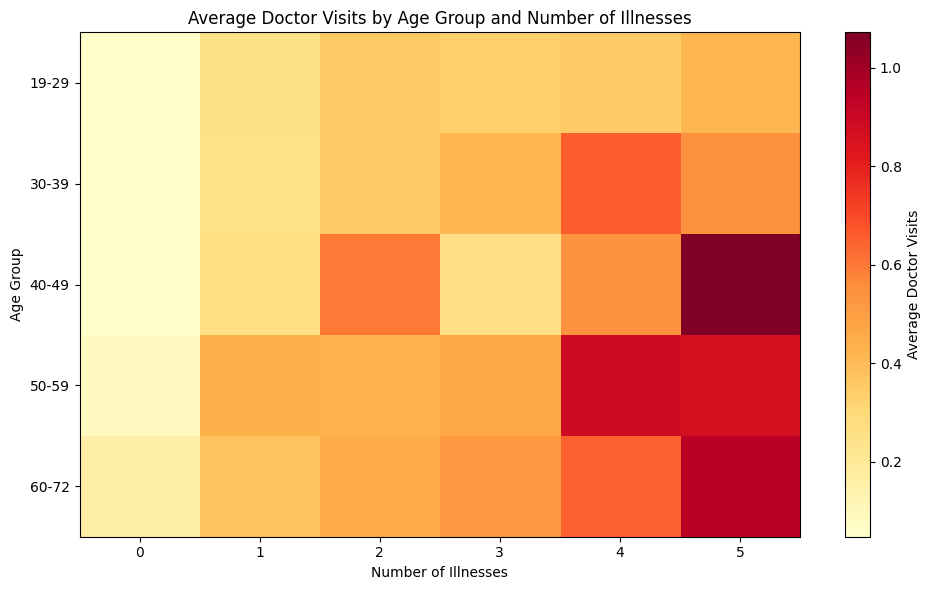

In [27]:
age_illness = pd.pivot_table(df,values="visits",index="age_group",columns="illness",aggfunc="mean",observed=False)
plt.figure(figsize=(10, 6))
plt.imshow(age_illness,cmap="YlOrRd",aspect="auto")
plt.colorbar(label="Average Doctor Visits")
plt.xticks(range(len(age_illness.columns)),age_illness.columns)
plt.yticks(range(len(age_illness.index)),age_illness.index.astype(str))
plt.xlabel("Number of Illnesses")
plt.ylabel("Age Group")
plt.title("Average Doctor Visits by Age Group and Number of Illnesses")
plt.tight_layout()
plt.show()

Insight: Older patients with more illnesses have the highest average visit rates, indicating a compounding effect of age and disease burden. This pattern supports targeted care planning for older, higher-risk patients.

### How does the number of days with reduced activity relate to doctor visits?

This analysis examines whether reduced mobility or activity is a meaningful signal of healthcare demand. Patients with more restricted days often require greater medical attention, so the relationship can indicate illness severity and functional impact. It highlights how health limitations translate into care utilization.

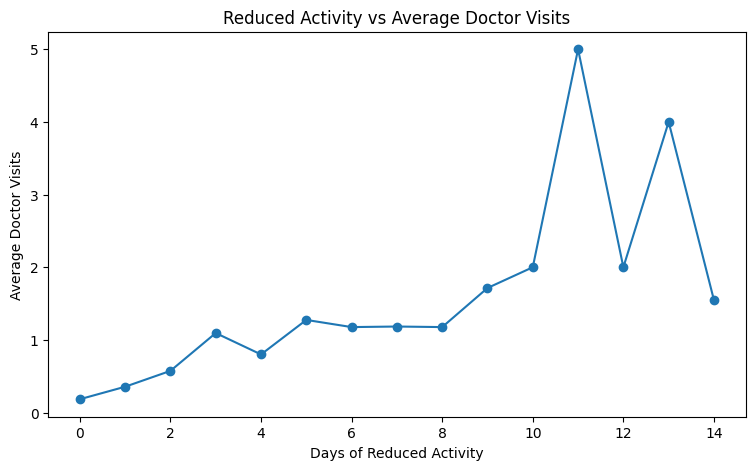

In [28]:
reduced_visits = df.groupby("reduced")["visits"].mean()
plt.figure(figsize=(9, 5))
plt.plot(reduced_visits.index, reduced_visits.values, marker="o")
plt.xlabel("Days of Reduced Activity")
plt.ylabel("Average Doctor Visits")
plt.title("Reduced Activity vs Average Doctor Visits")
plt.show()

Insight: As the number of reduced-activity days rises, doctor visits rise sharply. This means reduced activity is a strong indicator of poor health and a practical marker for identifying patients who may need more medical support.